# Notebook 03 — Fama-French 3-Factor Decomposition

## Objective
Extend CAPM to the **Fama-French 3-Factor model** and see how much of each stock's return is explained by three systematic factors vs. a single market factor.

## The Model
$$R_i - R_f = \alpha_i + \beta_{1i}(R_m - R_f) + \beta_{2i} \cdot SMB + \beta_{3i} \cdot HML + \epsilon_i$$

- $R_m - R_f$ = **Market** excess return
- $SMB$ = **Small Minus Big** — size factor
- $HML$ = **High Minus Low** — value factor

**Negative HML** → growth stock. **Positive HML** → value stock.

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
import io, zipfile, urllib.request
import warnings
warnings.filterwarnings('ignore')

# ── Dark theme — applied once globally ───────────────────────────────────────
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor'  : '#0D0D0D',
    'axes.facecolor'    : '#0D0D0D',
    'axes.edgecolor'    : '#444444',
    'axes.labelcolor'   : '#CCCCCC',
    'axes.titlecolor'   : '#FFFFFF',
    'xtick.color'       : '#AAAAAA',
    'ytick.color'       : '#AAAAAA',
    'grid.color'        : '#2A2A2A',
    'grid.linewidth'    : 0.6,
    'legend.facecolor'  : '#1A1A1A',
    'legend.edgecolor'  : '#444444',
    'legend.labelcolor' : '#CCCCCC',
    'text.color'        : '#FFFFFF',
    'font.size'         : 10,
})

# ── Portfolio Configuration ───────────────────────────────────────────────────
TICKERS      = ['AAPL', 'JPM', 'XOM', 'JNJ', 'AMZN']
START        = '2018-01-01'
END          = '2024-01-01'

COLORS       = ['#29B6F6', '#FF7043', '#66BB6A', '#CE93D8', '#FFB300']
STOCK_COLORS = dict(zip(TICKERS, COLORS))

print(f"Portfolio : {TICKERS}")
print(f"Period    : {START} → {END}")

Portfolio : ['AAPL', 'JPM', 'XOM', 'JNJ', 'AMZN']
Period    : 2018-01-01 → 2024-01-01


## 2. Download Stock Data & Fama-French Factors

In [2]:
prices  = yf.download(TICKERS, start=START, end=END)['Close']
returns = np.log(prices / prices.shift(1)).dropna()
print(f"Stock data downloaded — shape: {returns.shape}")

[*********************100%***********************]  5 of 5 completed

Stock data downloaded — shape: (1508, 5)


In [3]:
FF_URL = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip"

try:
    with urllib.request.urlopen(FF_URL) as response:
        zip_data = response.read()
    with zipfile.ZipFile(io.BytesIO(zip_data)) as z:
        fname = [f for f in z.namelist() if f.endswith('.CSV') or f.endswith('.csv')][0]
        with z.open(fname) as f:
            raw = f.read().decode('utf-8', errors='ignore')
    lines = raw.split('\n')
    start_line = 0
    for i, line in enumerate(lines):
        if line.strip().startswith('19') or line.strip().startswith('20'):
            start_line = i
            break
    data_lines = []
    for line in lines[start_line:]:
        parts = line.strip().split(',')
        if len(parts) >= 5 and len(parts[0].strip()) == 8:
            try:
                int(parts[0].strip())
                data_lines.append(parts)
            except:
                break
    ff_df = pd.DataFrame(data_lines, columns=['Date','Mkt-RF','SMB','HML','RF'])
    ff_df['Date'] = pd.to_datetime(ff_df['Date'].str.strip(), format='%Y%m%d')
    ff_df.set_index('Date', inplace=True)
    ff_df = ff_df.apply(pd.to_numeric, errors='coerce').dropna() / 100
    print(f"FF factors loaded: {ff_df.shape}")
except Exception as e:
    print(f"Could not download FF data: {e}")
    print("Using synthetic factors for demonstration...")
    np.random.seed(42)
    dates = returns.index
    ff_df = pd.DataFrame({
        'Mkt-RF': np.random.normal(0.0003, 0.01,  len(dates)),
        'SMB'   : np.random.normal(0.0001, 0.005, len(dates)),
        'HML'   : np.random.normal(0.0001, 0.005, len(dates)),
        'RF'    : np.full(len(dates), 0.00005)
    }, index=dates)

FF factors loaded: (26190, 4)


## 3. Align Data & Run FF3 Regression

In [4]:
ff_aligned  = ff_df[['Mkt-RF','SMB','HML','RF']].reindex(returns.index).dropna()
ret_aligned = returns.reindex(ff_aligned.index).dropna()
ff_aligned  = ff_aligned.reindex(ret_aligned.index)
print(f"Aligned data points: {len(ret_aligned)}")

def run_ff3(stock_excess_ret, ff_factors):
    X         = sm.add_constant(ff_factors[['Mkt-RF','SMB','HML']])
    model     = sm.OLS(stock_excess_ret, X).fit()
    total_var = stock_excess_ret.var()
    idio_var  = model.resid.var()
    sys_var   = total_var - idio_var
    return {
        'alpha'     : model.params['const'],
        'beta_mkt'  : model.params['Mkt-RF'],
        'beta_smb'  : model.params['SMB'],
        'beta_hml'  : model.params['HML'],
        'r_squared' : model.rsquared,
        'total_var' : total_var,
        'sys_var'   : sys_var,
        'idio_var'  : idio_var,
        'sys_pct'   : sys_var  / total_var * 100,
        'idio_pct'  : idio_var / total_var * 100,
        'model'     : model
    }

ff_results = {}
for ticker in TICKERS:
    excess_ret          = ret_aligned[ticker] - ff_aligned['RF']
    ff_results[ticker]  = run_ff3(excess_ret, ff_aligned)

ff_summary = pd.DataFrame({
    'Alpha'        : {t: ff_results[t]['alpha']     for t in TICKERS},
    'β Market'     : {t: ff_results[t]['beta_mkt']  for t in TICKERS},
    'β SMB'        : {t: ff_results[t]['beta_smb']  for t in TICKERS},
    'β HML'        : {t: ff_results[t]['beta_hml']  for t in TICKERS},
    'R²'           : {t: ff_results[t]['r_squared'] for t in TICKERS},
    'Systematic %' : {t: ff_results[t]['sys_pct']   for t in TICKERS},
    'Idiosync. %'  : {t: ff_results[t]['idio_pct']  for t in TICKERS},
}).round(4)

print("\n── Fama-French 3-Factor Summary ──────────────────────────────────")
print(ff_summary.to_string())

Aligned data points: 1508

── Fama-French 3-Factor Summary ──────────────────────────────────
       Alpha  β Market   β SMB   β HML      R²  Systematic %  Idiosync. %
AAPL  0.0004    1.2032 -0.3352 -0.3889  0.6860       68.5962      31.4038
JPM  -0.0001    1.1174 -0.1584  0.8619  0.7660       76.6018      23.3982
XOM  -0.0001    0.9068  0.0535  0.9507  0.5545       55.4473      44.5527
JNJ  -0.0002    0.5643 -0.4806  0.0864  0.3536       35.3587      64.6413
AMZN -0.0000    1.1023 -0.1667 -0.7433  0.5806       58.0561      41.9439


## 4. Visualisations

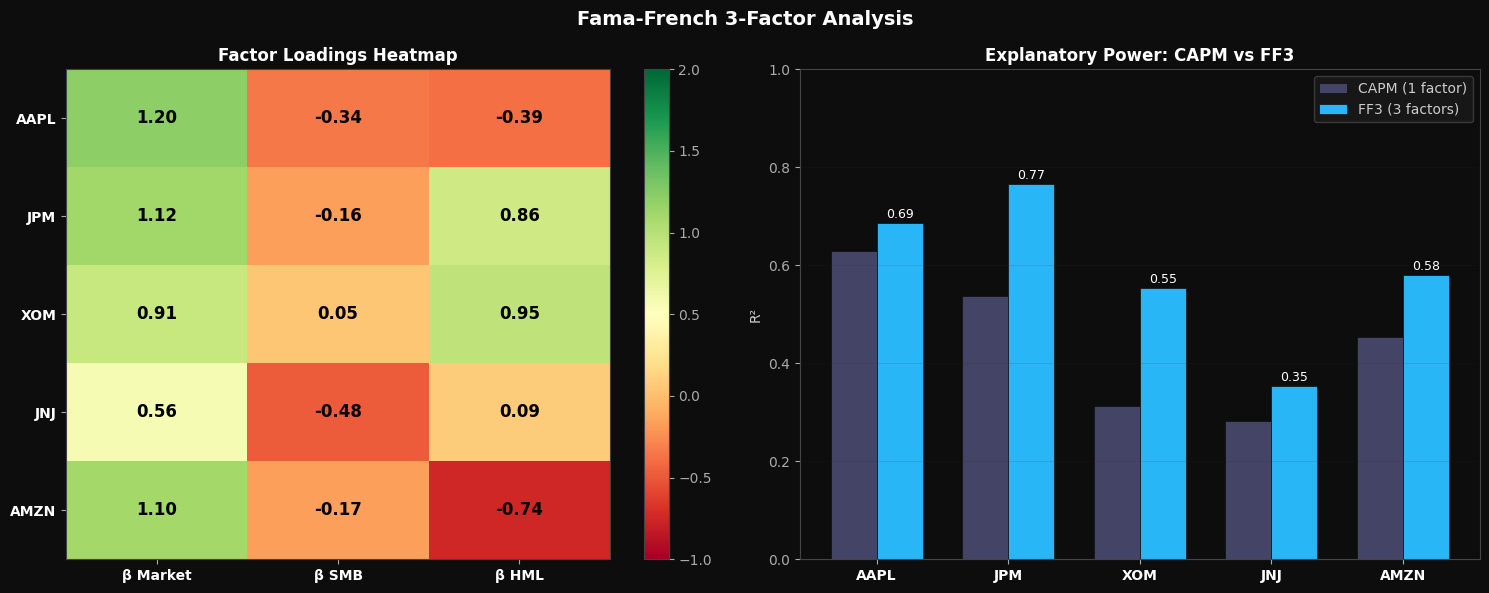

In [5]:
# ── Plot 1: Factor loadings heatmap + R² comparison ───────────────────────────
factors  = ['β Market', 'β SMB', 'β HML']
loadings = np.array([[ff_results[t]['beta_mkt'],
                      ff_results[t]['beta_smb'],
                      ff_results[t]['beta_hml']] for t in TICKERS])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Fama-French 3-Factor Analysis',
             fontsize=14, fontweight='bold', color='white')
fig.patch.set_facecolor('#0D0D0D')

# Heatmap
ax = axes[0]
im = ax.imshow(loadings, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=2)
ax.set_xticks(range(len(factors)))
ax.set_yticks(range(len(TICKERS)))
ax.set_xticklabels(factors, fontweight='bold', color='white')
ax.set_yticklabels(TICKERS, fontweight='bold', color='white')
ax.set_title('Factor Loadings Heatmap', fontweight='bold', color='white')
plt.colorbar(im, ax=ax)
for i in range(len(TICKERS)):
    for j in range(len(factors)):
        ax.text(j, i, f'{loadings[i,j]:.2f}',
                ha='center', va='center',
                fontsize=12, fontweight='bold', color='black')

# R² comparison CAPM vs FF3
ax2      = axes[1]
capm_r2  = []
for ticker in TICKERS:
    excess = ret_aligned[ticker] - ff_aligned['RF']
    X      = sm.add_constant(ff_aligned['Mkt-RF'])
    capm_r2.append(sm.OLS(excess, X).fit().rsquared)

ff3_r2 = [ff_results[t]['r_squared'] for t in TICKERS]
x      = np.arange(len(TICKERS))
w      = 0.35

bars1 = ax2.bar(x - w/2, capm_r2, w,
                label='CAPM (1 factor)',
                color='#444466', edgecolor='#0D0D0D', linewidth=0.5)
bars2 = ax2.bar(x + w/2, ff3_r2, w,
                label='FF3 (3 factors)',
                color='#29B6F6', edgecolor='#0D0D0D', linewidth=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(TICKERS, fontweight='bold', color='white')
ax2.set_ylabel('R²', color='#CCCCCC')
ax2.set_title('Explanatory Power: CAPM vs FF3',
              fontweight='bold', color='white')
ax2.legend()
ax2.set_ylim(0, 1)
ax2.grid(True, axis='y', alpha=0.15)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.2f}',
             ha='center', fontsize=9, color='white')

plt.tight_layout()
plt.show()


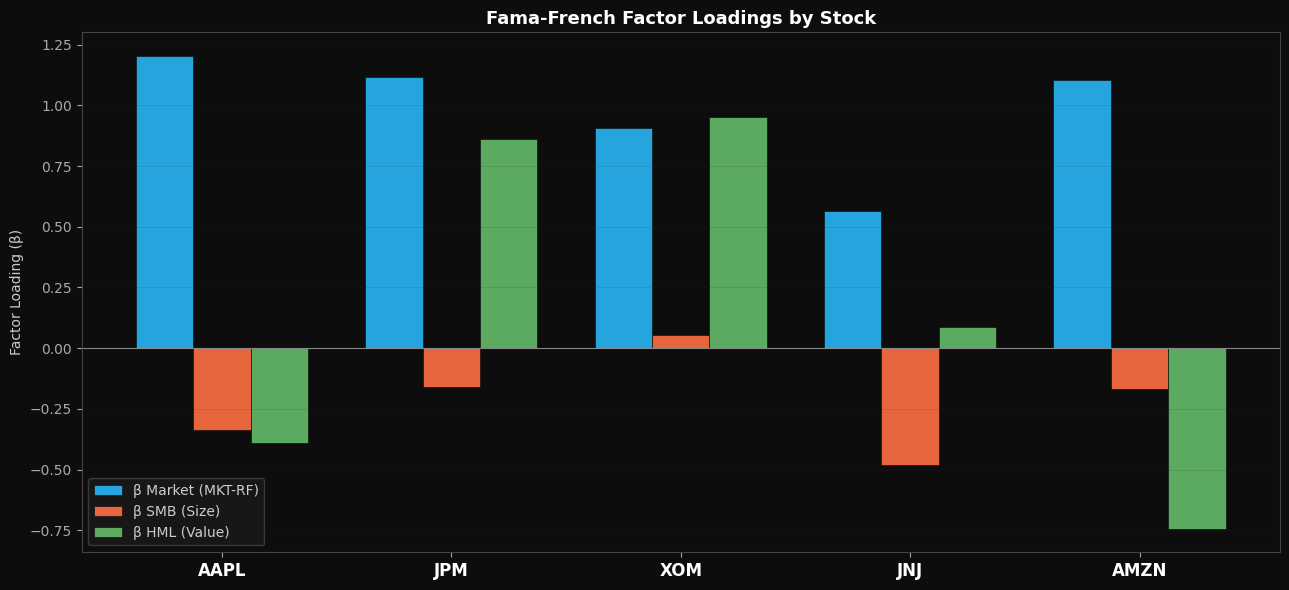

In [6]:
# ── Plot 2: Factor loadings grouped bar ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0D0D0D')

x         = np.arange(len(TICKERS))
w         = 0.25
mkt_betas = [ff_results[t]['beta_mkt'] for t in TICKERS]
smb_betas = [ff_results[t]['beta_smb'] for t in TICKERS]
hml_betas = [ff_results[t]['beta_hml'] for t in TICKERS]

ax.bar(x - w,  mkt_betas, w, label='β Market (MKT-RF)',
       color='#29B6F6', alpha=0.9, edgecolor='#0D0D0D', linewidth=0.5)
ax.bar(x,      smb_betas, w, label='β SMB (Size)',
       color='#FF7043', alpha=0.9, edgecolor='#0D0D0D', linewidth=0.5)
ax.bar(x + w,  hml_betas, w, label='β HML (Value)',
       color='#66BB6A', alpha=0.9, edgecolor='#0D0D0D', linewidth=0.5)

ax.axhline(0, color='#888888', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(TICKERS, fontweight='bold', fontsize=12, color='white')
ax.set_ylabel('Factor Loading (β)', color='#CCCCCC')
ax.set_title('Fama-French Factor Loadings by Stock',
             fontsize=13, fontweight='bold', color='white')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.15)

plt.tight_layout()
plt.show()


## 5. Key Findings

In [7]:
print("=" * 65)
print("  FAMA-FRENCH 3-FACTOR DECOMPOSITION — KEY FINDINGS")
print("=" * 65)

for ticker in TICKERS:
    r         = ff_results[ticker]
    smb_style = 'large-cap tilt' if r['beta_smb'] < 0 else 'small-cap tilt'
    hml_style = 'growth stock'   if r['beta_hml'] < 0 else 'value stock'
    print(f"\n{ticker}")
    print(f"  β Market : {r['beta_mkt']:.3f}")
    print(f"  β SMB    : {r['beta_smb']:.3f}  → {smb_style}")
    print(f"  β HML    : {r['beta_hml']:.3f}  → {hml_style}")
    print(f"  R²       : {r['r_squared']:.3f}  ({r['r_squared']*100:.1f}% explained by 3 factors)")
    print(f"  Alpha    : {r['alpha']*100:.4f}% per day")

print("\n" + "=" * 65)
best_alpha = max(TICKERS, key=lambda t: ff_results[t]['alpha'])
best_r2    = max(TICKERS, key=lambda t: ff_results[t]['r_squared'])
print(f"  Highest alpha  : {best_alpha} ({ff_results[best_alpha]['alpha']*100:.4f}%/day)")
print(f"  Best explained : {best_r2} (R²={ff_results[best_r2]['r_squared']:.3f})")
print("=" * 65)

  FAMA-FRENCH 3-FACTOR DECOMPOSITION — KEY FINDINGS

AAPL
  β Market : 1.203
  β SMB    : -0.335  → large-cap tilt
  β HML    : -0.389  → growth stock
  R²       : 0.686  (68.6% explained by 3 factors)
  Alpha    : 0.0359% per day

JPM
  β Market : 1.117
  β SMB    : -0.158  → large-cap tilt
  β HML    : 0.862  → value stock
  R²       : 0.766  (76.6% explained by 3 factors)
  Alpha    : -0.0085% per day

XOM
  β Market : 0.907
  β SMB    : 0.054  → small-cap tilt
  β HML    : 0.951  → value stock
  R²       : 0.554  (55.4% explained by 3 factors)
  Alpha    : -0.0087% per day

JNJ
  β Market : 0.564
  β SMB    : -0.481  → large-cap tilt
  β HML    : 0.086  → value stock
  R²       : 0.354  (35.4% explained by 3 factors)
  Alpha    : -0.0156% per day

AMZN
  β Market : 1.102
  β SMB    : -0.167  → large-cap tilt
  β HML    : -0.743  → growth stock
  R²       : 0.581  (58.1% explained by 3 factors)
  Alpha    : -0.0033% per day

  Highest alpha  : AAPL (0.0359%/day)
  Best explained : J